In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Set plot aesthetics
plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid")

# Import your custom utility for automated model evaluation!
import sys
sys.path.append('./ml_utils')
from mesh_utils_optimized import find_best_model

In [2]:
print("Loading dataset...")
df = pd.read_csv("movie_metadata.csv")

# Drop rows where the target variable is missing
df = df.dropna(subset=['imdb_score'])

# Drop columns that offer no predictive value (e.g., URLs)
if 'movie_imdb_link' in df.columns:
    df = df.drop(columns=['movie_imdb_link'])

Loading dataset...


In [3]:
print("Imputing missing values...")
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numericals with median
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categoricals with 'Unknown' or mode
for col in cat_cols:
    if col in ['director_name', 'actor_1_name', 'actor_2_name', 'actor_3_name', 'plot_keywords']:
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Creating target variable 'Classify'...")
bins = [0, 3, 6, 10]
labels = ['Flop', 'Average', 'Hit']
df['Classify'] = pd.cut(df['imdb_score'], bins=bins, labels=labels, include_lowest=True)

# CRITICAL: Drop the imdb_score so the model doesn't cheat!
df = df.drop(columns=['imdb_score'])

Imputing missing values...
Creating target variable 'Classify'...


2. Feature Relationships and Outlier Detection


C:\Users\soume\AppData\Local\Temp\ipykernel_15584\2363552041.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Classify', y='budget', order=['Flop', 'Average', 'Hit'], palette='viridis', ax=axes[0])
C:\Users\soume\AppData\Local\Temp\ipykernel_15584\2363552041.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Classify', y='cast_total_facebook_likes', order=['Flop', 'Average', 'Hit'], palette='viridis', ax=axes[1])


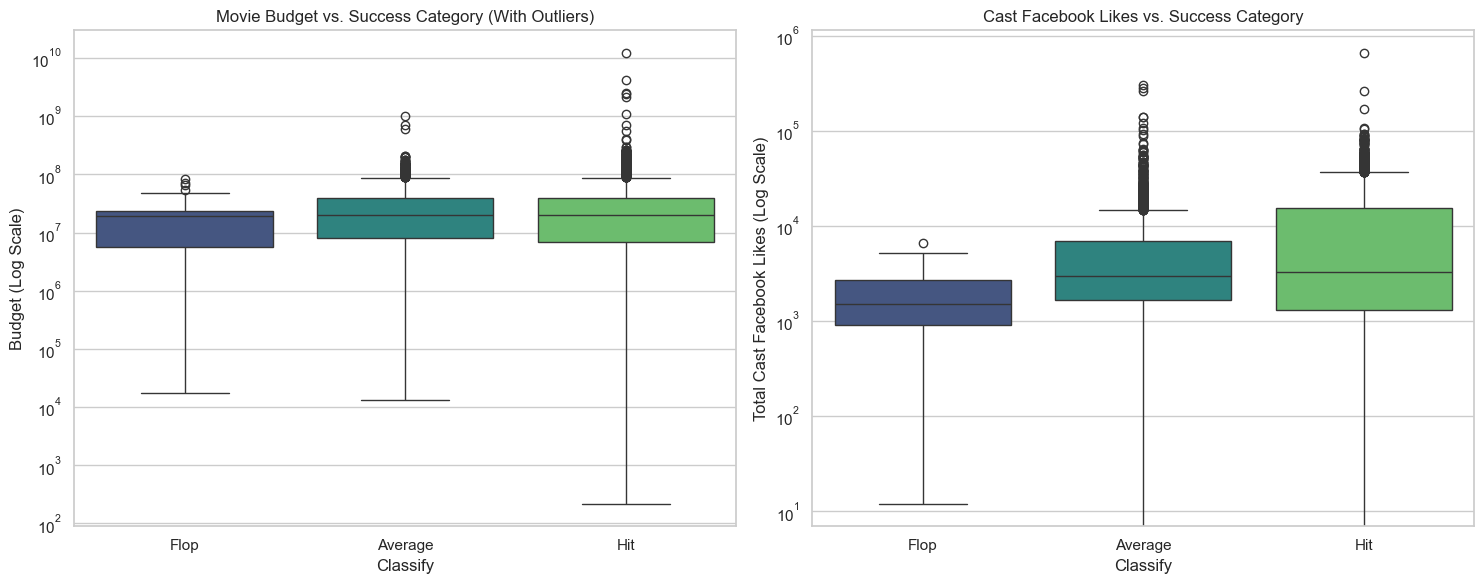

In [4]:
print("2. Feature Relationships and Outlier Detection")

required_cols = ['budget', 'cast_total_facebook_likes', 'Classify']
if all(col in df.columns for col in required_cols):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    sns.boxplot(data=df, x='Classify', y='budget', order=['Flop', 'Average', 'Hit'], palette='viridis', ax=axes[0])
    axes[0].set_title('Movie Budget vs. Success Category (With Outliers)')
    axes[0].set_yscale('log')
    axes[0].set_ylabel('Budget (Log Scale)')

    sns.boxplot(data=df, x='Classify', y='cast_total_facebook_likes', order=['Flop', 'Average', 'Hit'], palette='viridis', ax=axes[1])
    axes[1].set_title('Cast Facebook Likes vs. Success Category')
    axes[1].set_yscale('log')
    axes[1].set_ylabel('Total Cast Facebook Likes (Log Scale)')

    plt.tight_layout()
    plt.show()
else:
    missing_cols = [col for col in required_cols if col not in df.columns]
    print(f"Skipped outlier boxplots; missing columns: {missing_cols}")

--- Exploratory Data Analysis (EDA) ---
1. Target Variable Distribution


C:\Users\soume\AppData\Local\Temp\ipykernel_15584\82355204.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Classify', order=['Flop', 'Average', 'Hit'], palette='viridis')


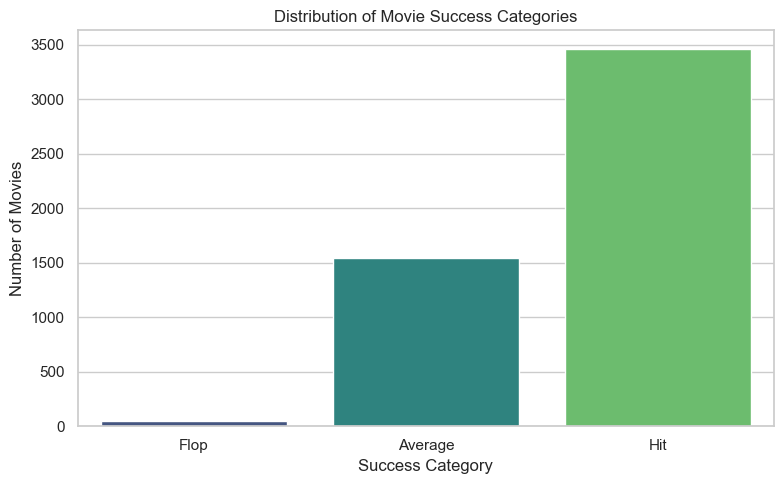

Note: This highlights class imbalance; F1-based evaluation helps handle this.


In [5]:
print("--- Exploratory Data Analysis (EDA) ---")
print("1. Target Variable Distribution")
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Classify', order=['Flop', 'Average', 'Hit'], palette='viridis')
plt.title('Distribution of Movie Success Categories')
plt.ylabel('Number of Movies')
plt.xlabel('Success Category')
plt.tight_layout()
plt.show()
print("Note: This highlights class imbalance; F1-based evaluation helps handle this.")

In [6]:
print("Addressing multicollinearity...")
num_features = df.select_dtypes(include=[np.number])
corr_matrix = num_features.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.80)]

print(f"Dropping highly correlated columns: {to_drop}")
df = df.drop(columns=to_drop)

# Separate Features (X) and Target (y)
X = df.drop(columns=['Classify'])
y = df['Classify']

Addressing multicollinearity...
Dropping highly correlated columns: ['cast_total_facebook_likes']


In [7]:
print("Splitting data into Train and Test sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Splitting data into Train and Test sets...
Training set shape: (4034, 25)
Testing set shape: (1009, 25)


In [8]:
print("Encoding and Scaling features safely...")

# Identify categorical and numerical columns in the updated X
cat_cols_X = X_train.select_dtypes(include=['object', 'category']).columns
num_cols_X = X_train.select_dtypes(include=[np.number]).columns

# Fulfilling the label encoding requirement using OrdinalEncoder to safely handle unseen test data.
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

if len(cat_cols_X) > 0:
    X_train_encoded[cat_cols_X] = encoder.fit_transform(X_train[cat_cols_X])
    X_test_encoded[cat_cols_X] = encoder.transform(X_test[cat_cols_X])

# 2. Scale Numericals
scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[num_cols_X] = scaler.fit_transform(X_train_encoded[num_cols_X])
X_test_scaled[num_cols_X] = scaler.transform(X_test_encoded[num_cols_X])

print("Transformations applied perfectly without data leakage.")

Encoding and Scaling features safely...
Transformations applied perfectly without data leakage.


In [9]:
print("--- Running Automated Model Selection & Tuning ---")
print("Evaluating multiple models via RandomizedSearchCV...")

from sklearn.preprocessing import LabelEncoder

# Encode target labels for broader model compatibility (e.g., XGBoost)
target_encoder = LabelEncoder()
y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

# Run custom randomized search utility on already leakage-safe transformed data
best_model_results = find_best_model(
    x=X_train_scaled,
    y=y_train_encoded,
    problem_type='classification',
    metric='f1',  # maps to f1_weighted in util script
    n_iter=10,
    x_test=X_test_scaled,
    y_test=y_test_encoded,
    cv=5
)

print(f"\nBest Model Found: {best_model_results['best_model_name']}")
print(f"Optimal Parameters: {best_model_results['best_params']}")
print(f"Cross-Validation F1 Score: {best_model_results['CV_score']:.4f}")
print(f"Holdout Test F1 Score: {best_model_results['Test_score']:.4f}")

# Extract best estimator and produce human-readable predictions
best_model = best_model_results['trained_model']
y_pred_encoded = best_model.predict(X_test_scaled)
y_pred = target_encoder.inverse_transform(y_pred_encoded)

print("\n--- Classification Report for Best Model ---")
print(classification_report(y_test, y_pred, zero_division=0))

--- Running Automated Model Selection & Tuning ---
Evaluating multiple models via RandomizedSearchCV...
Training models for classification using f1 (RandomizedSearchCV)...


C:\Users\soume\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Best Model Found: xgboost
Optimal Parameters: {'subsample': 0.6, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2}
Cross-Validation F1 Score: 0.7960
Holdout Test F1 Score: 0.7877

--- Classification Report for Best Model ---
              precision    recall  f1-score   support

     Average       0.68      0.63      0.65       308
        Flop       0.00      0.00      0.00         9
         Hit       0.84      0.88      0.86       692

    accuracy                           0.79      1009
   macro avg       0.51      0.50      0.50      1009
weighted avg       0.78      0.79      0.79      1009



--- Random Forest Emphasis (Rubric Requirement) ---
Random Forest Classification Report
              precision    recall  f1-score   support

     Average       0.63      0.72      0.67       308
        Flop       0.00      0.00      0.00         9
         Hit       0.87      0.82      0.84       692

    accuracy                           0.78      1009
   macro avg       0.50      0.51      0.51      1009
weighted avg       0.79      0.78      0.78      1009



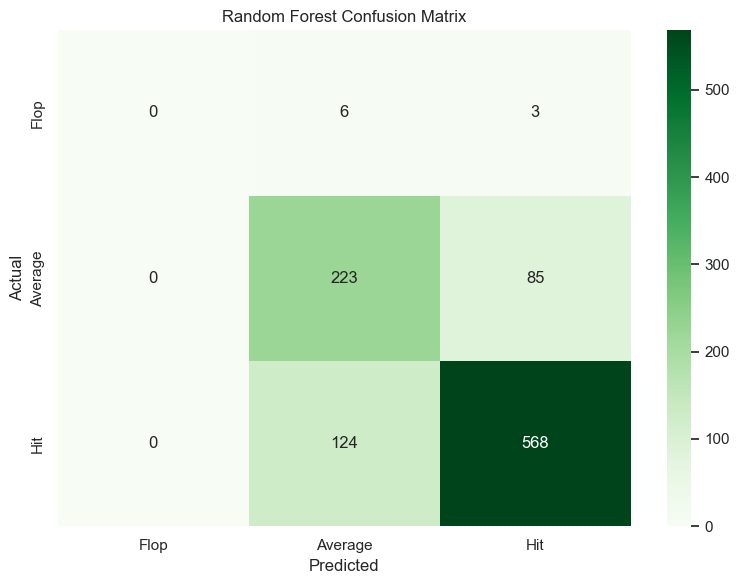

In [10]:
print("--- Random Forest Emphasis (Rubric Requirement) ---")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train_encoded)
rf_pred_encoded = rf_model.predict(X_test_scaled)
rf_pred = target_encoder.inverse_transform(rf_pred_encoded)

print("Random Forest Classification Report")
print(classification_report(y_test, rf_pred, zero_division=0))

plt.figure(figsize=(8, 6))
labels_order = ['Flop', 'Average', 'Hit']
sns.heatmap(
    confusion_matrix(y_test, rf_pred, labels=labels_order),
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=labels_order,
    yticklabels=labels_order
)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Generating Confusion Matrix for xgboost...


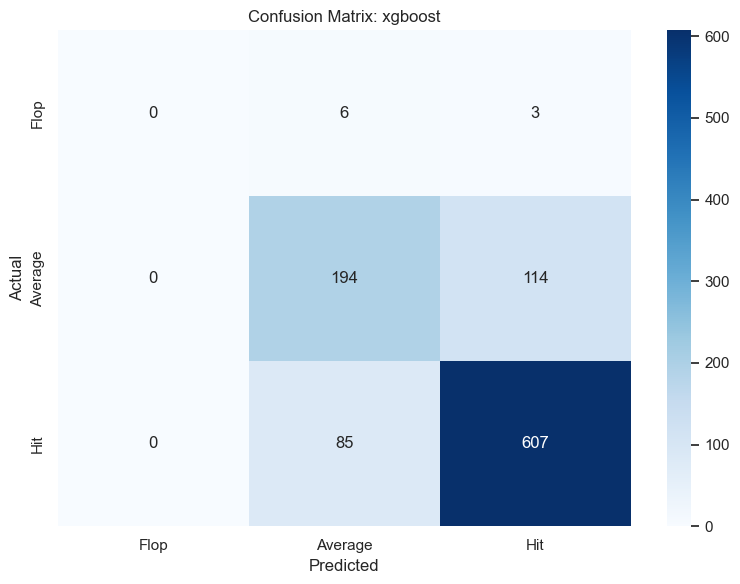

In [11]:
print(f"Generating Confusion Matrix for {best_model_results['best_model_name']}...")
plt.figure(figsize=(8, 6))
labels_order = ['Flop', 'Average', 'Hit']

sns.heatmap(
    confusion_matrix(y_test, y_pred, labels=labels_order),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_order,
    yticklabels=labels_order
)

plt.title(f"Confusion Matrix: {best_model_results['best_model_name']}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [12]:
print("Exporting the best model and preprocessors...")
models_dir = './models'
os.makedirs(models_dir, exist_ok=True)

# Save the winning model dynamically
model_filename = f"best_movie_model_{best_model_results['best_model_name'].replace(' ', '_').lower()}.pkl"
joblib.dump(best_model, os.path.join(models_dir, model_filename))

# Save the scaler and encoder
joblib.dump(scaler, os.path.join(models_dir, 'standard_scaler.pkl'))
joblib.dump(encoder, os.path.join(models_dir, 'ordinal_encoder.pkl'))
joblib.dump(target_encoder, os.path.join(models_dir, 'target_label_encoder.pkl'))

print(f"Successfully exported {best_model_results['best_model_name']}, Scaler, Encoder, and Target Encoder to the '{models_dir}' directory.")

Exporting the best model and preprocessors...
Successfully exported xgboost, Scaler, Encoder, and Target Encoder to the './models' directory.
